### Numpy youtube数据读取练习，并通过matplotlib绘制直方图

In [3]:
import pandas as pd
import os

# 假设数据文件夹名为 'youtube_video_data'
data_dir = 'youtube_video_data'
us_file = os.path.join(data_dir, 'USvideos.csv')

if os.path.exists(us_file):
    # 读取csv文件
    df_us = pd.read_csv(us_file)
    print(f"去重前行数: {len(df_us)}")
    # 按视频id去重（假定列名为 'video_id'）
    if 'video_id' in df_us.columns:
        df_us_dedup = df_us.drop_duplicates(subset='video_id')
        print(f"去重后行数: {len(df_us_dedup)}")
        print(f"前5个去重后的视频ID: {df_us_dedup['video_id'].head().tolist()}")
    else:
        print("列 'video_id' 不存在，请检查数据表头。")
else:
    print(f"未找到文件: {us_file}")
     

去重前行数: 1688
去重后行数: 566
前5个去重后的视频ID: ['XpVt6Z1Gjjo', 'K4wEI5zhHB0', 'cLdxuaxaQwc', 'WYYvHb03Eog', 'sjlHnJvXdQs']


每个种类电影的数量：
category_id
1      34
2      11
10     90
15      7
17     34
19      6
20      5
22     57
23     46
24    110
25     45
26     55
27     19
28     46
29      1
Name: count, dtype: int64


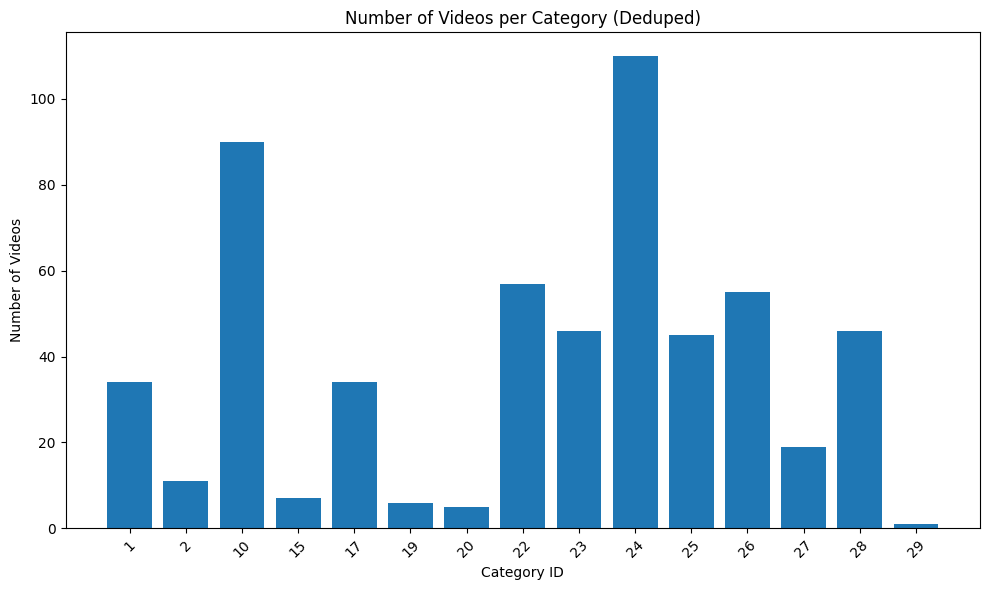

In [4]:
import matplotlib.pyplot as plt

# 确保我们有去重后的DataFrame
if 'df_us_dedup' in locals():
    # 检查是否有 'category_id' 列
    if 'category_id' in df_us_dedup.columns:
        category_counts = df_us_dedup['category_id'].value_counts().sort_index()
        print("每个种类电影的数量：")
        print(category_counts)

        plt.figure(figsize=(10,6))
        plt.bar(category_counts.index.astype(str), category_counts.values)
        plt.xlabel('Category ID')
        plt.ylabel('Number of Videos')
        plt.title('Number of Videos per Category (Deduped)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("列 'category_id' 不存在，请检查数据表头。")
else:
    print("未找到去重后的 DataFrame，请确保上一步已成功执行。")